In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm
from scipy.optimize import curve_fit
import pandas as pd

# Read size distribution from file, fit model distribution, and plot

In [2]:
# Define model distribution wrapper, to pass to curve fit
def f(x, w1, s1, scale1, w2, s2, scale2):
    # Weighted sum of two log normal distributions
    p1 = lognorm(s=s1, scale=scale1)
    p2 = lognorm(s=s2, scale=scale2)
    return w1*p1.pdf(x) + w2*p2.pdf(x)

Text(0, 0.5, 'Probability (not normalised)')

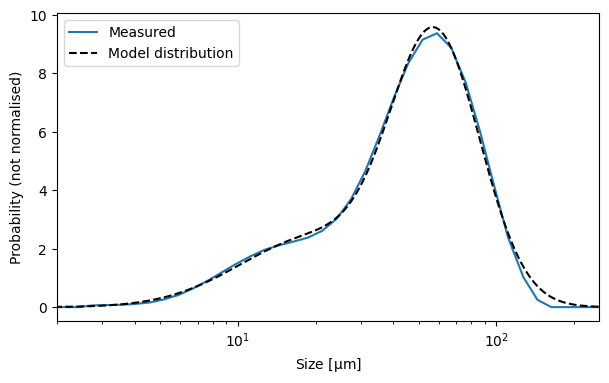

In [3]:
fig = plt.figure(figsize=(7,4))

# Read size distribution from data file
df = pd.read_csv('./data/25P45.txt', comment='#')
X, Y = df['Size [um]'], df['Density']
# Plot
plt.plot(X, Y, label='Measured')

# Initial parameter guess
p0=[500, 0.5, 50, 500, 0.5, 50]
# Bounds on parameters
bounds = (
    (0,0,0,0,0,0),
    (1000, 1, 100, 1000, 1, 100)
)
# Fit model distribution
popt, pcov = curve_fit(f, X, Y, p0=p0, bounds=bounds)
# Plot model distribution at higher resolution
x = np.logspace(0, 3, 1000)
plt.plot(x, f(x, *popt), '--', c='k', label='Model distribution')

plt.xscale('log')
plt.xlim(2, 250)
plt.legend()
plt.xlabel('Size [$\\mathrm{\\mu{}m}$]')
plt.ylabel('Probability (not normalised)')

# Random sampling

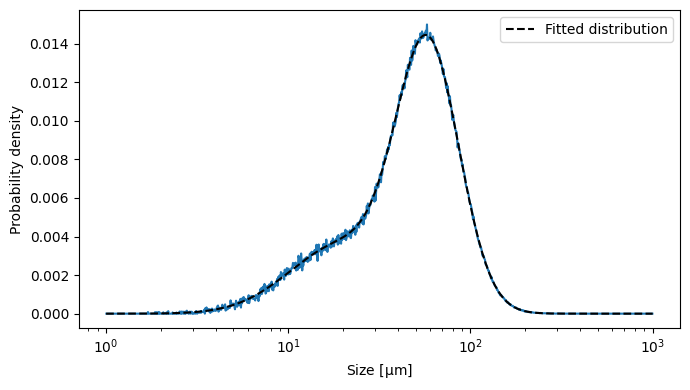

In [4]:
# Draw sizes from the fitted pdfs
Np = 1000000 # Number of samples

# Fitted parameters
w1, s1, scale1, w2, s2, scale2 = popt

# Create pdfs
p1 = lognorm(s=s1, scale=scale1)
p2 = lognorm(s=s2, scale=scale2)

# Normalise weights to find number of samples from each distribution
N1 = int(Np * w1/(w1+w2))
N2 = Np - N1

# Draw samples
d = np.concatenate((p1.rvs(size=N1), p2.rvs(size=N2)))

# Make histogram
bins = np.logspace(0, 3, 1000)
mids = np.sqrt(bins[:-1]*bins[1:])
h, _ = np.histogram(d, bins, density=True)


fig = plt.figure(figsize=(7,4))
# plot histogram
plt.plot(mids, h, zorder=0)
# Plot model distribution, with normalised weights
plt.plot(x, f(x, w1/(w1+w2), s1, scale1, w2/(w1+w2), s2, scale2), '--', c='k', label='Fitted distribution')


plt.xscale('log')
plt.xlabel('Size [$\\mathrm{\\mu{}m}$]')
plt.ylabel('Probability density')
plt.legend()
plt.tight_layout()
plt.savefig('size_distribution_monte_carlo.png', dpi=240, bbox_inches='tight')

# Calculate effective density as function of wall thickness

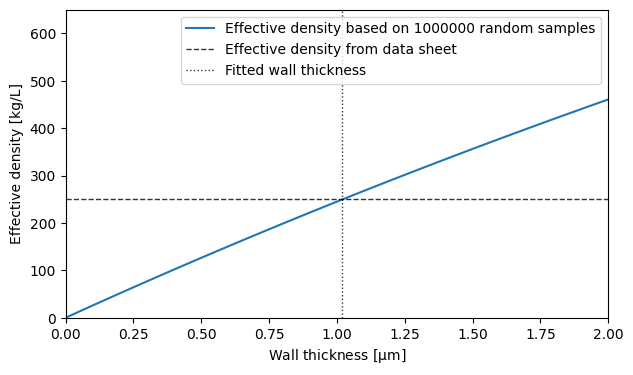

In [5]:
# Wall thicknesses, in m
h_list = 1e-6 * np.linspace(0., 2, 50)
# Glass density
rho_glass = 2230 # kg / m3
# Number of samples
N = 1000000

# Normalise weights to find number of samples from each distribution
N1 = int(Np * w1/(w1+w2))
N2 = Np - N1
# Draw sizes and rescale to m
d = 1e-6 * np.concatenate((p1.rvs(size=N1), p2.rvs(size=N2)))
# volume as function of size
V = (4/3)*np.pi*(d/2)**3

# Calculate average effective density
rho_eff = np.zeros(len(h_list))
for i, h in enumerate(h_list):

    # Calculate weights to go from volume to number distribution
    n = 1 / V
    # mass as a function of size
    # For spheres with r > h, assume hollow glass shell
    M1 = rho_glass * ((4/3)*np.pi*(d/2)**3 - (4/3)*np.pi*(d/2-h)**3)
    # For spheres with r <= h, assume solid glass sphere
    M2 = rho_glass *  (4/3)*np.pi*(d/2)**3
    # Combine with where
    M = np.where(d/2 > h, M1, M2)

    # Effective density
    rho_eff[i] = np.sum(n*M) / np.sum(n*V)


fig = plt.figure(figsize=(7, 4))
plt.plot(h_list*1e6, rho_eff, label=f'Effective density based on {N} random samples')
plt.axhline(250, ls='--', c='k', lw=1, alpha=0.8, label='Effective density from data sheet')
plt.axvline(1.02, ls=':', c='k', lw=1, alpha=0.8, label='Fitted wall thickness')
plt.xlim(0, 2)
plt.ylim(0, 650)
plt.ylabel('Effective density [kg/L]')
plt.xlabel('Wall thickness [$\\mathrm{\\mu}$m]')
plt.legend()

# Density as function of size

(0.0, 2.27)

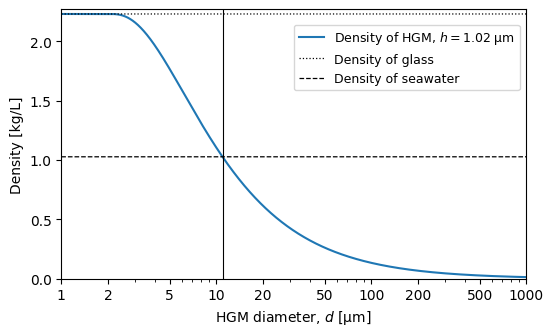

In [6]:
# Wall thickness
h = 1.02e-6
# Glass density
rho_glass = 2230 # kg / m3

d = np.logspace(-6, -3, 10000)

# For spheres with r > h, assume hollow glass shell
fig = plt.figure(figsize=(6,3.5))

for h in [1.02e-6]:
    rho_eff = np.where(d/2 > h,
        rho_glass * ((4/3)*np.pi*(d/2)**3 - (4/3)*np.pi*(d/2-h)**3) / ((4/3)*np.pi*(d/2)**3),
        rho_glass)
    plt.plot(1e6*d, rho_eff / 1000, label=f'Density of HGM, $h={h*1e6:.2f}\\;\\mathrm{{\\mu m}}$')

d_c = 1e6*d[np.argmin(np.abs(rho_eff - 1027))]

plt.plot([d_c, d_c], [0, 3], c='k', lw=0.8)
plt.plot(1e6*d, rho_glass / 1000 * np.ones_like(d), ':', lw=0.9, c='k', label='Density of glass')
plt.plot(1e6*d, 1027 / 1000 * np.ones_like(d), '--', lw=0.9, c='k', label='Density of seawater')
plt.xscale('log')
plt.ylabel('Density [kg/L]')
plt.xlabel('HGM diameter, $d$ [$\\mathrm{\\mu}$m]')
plt.xticks([1,2,5,10,20,50,100,200,500,1000], [1,2,5,10,20,50,100,200,500,1000])
plt.legend(loc=(0.5, 0.7), fontsize=9)
plt.xlim(1, 1e3)
plt.ylim(0, 2.27)

Sinking fraction:  0.2711782626416126


(0.05, 2.5)

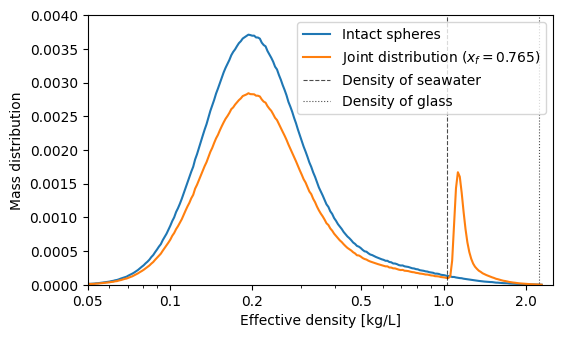

In [7]:
# Wall thickness
h = 1.02e-6
# Glass density
rho_glass = 2230 # kg / m3
# Water density
rho_water = 1025 # kg / m3
# Number of samples
Np = 10000000

# Normalise weights to find number of samples from each distribution
N1 = int(Np * w1/(w1+w2))
N2 = Np - N1
# Draw sizes and rescale to m
d = 1e-6 * np.concatenate((p1.rvs(size=N1), p2.rvs(size=N2)))
# volume as function of size
V = (4/3)*np.pi*(d/2)**3

# Calculate weights to go from volume to number distribution
n = 1 / V
# mass as a function of size

# Mass of intact spheres
# For spheres with r > h, assume hollow glass shell
M1 = rho_glass * ((4/3)*np.pi*(d/2)**3 - (4/3)*np.pi*((d-2*h)/2)**3)
# For spheres with r <= h, assume solid glass sphere
M2 = rho_glass *  (4/3)*np.pi*(d/2)**3
# Combine with where
M_intact = np.where(d/2 > h, M1, M2)

# Mass of cracked spheres
# For spheres with r > h, assume hollow glass shell
M1 = rho_glass * ((4/3)*np.pi*(d/2)**3 - (4/3)*np.pi*((d-2*h)/2)**3) + rho_water * (4/3)*np.pi*((d-2*h)/2)**3
# For spheres with r <= h, assume solid glass sphere
M2 = rho_glass *  (4/3)*np.pi*(d/2)**3
# Combine with where
M_cracked = np.where(d/2 > h, M1, M2)

#
xf = 0.765
intact = np.random.random(size=Np) < xf
M_joint = np.where(intact, M_intact, M_cracked)

# Density for each sphere
rho_intact = M_intact / V
rho_joint = M_joint / V

# Sinking fraction (fraction calculated by dry mass, density by joint (both intact and cracked))
print('Sinking fraction: ', np.sum((M_intact*n)[rho_joint > 1025]) / np.sum(M_intact*n))

# Make histogram
bins = np.logspace(np.log10(50), np.log10(2300), 240)

mids = np.sqrt(bins[:-1]*bins[1:])
hist_intact, _ = np.histogram(rho_intact, bins, density=True, weights=n*M_intact)
hist_joint, _ = np.histogram(rho_joint, bins, density=True, weights=n*M_intact) # Weighting by dry mass

# Plot results
fig = plt.figure(figsize=(6, 3.5))
plt.plot(mids/1000, hist_intact, label='Intact spheres')
plt.plot(mids/1000, hist_joint, label='Joint distribution ($x_f=0.765$)')
plt.plot([1.025, 1.025], [-1, 1], '--', c='k', lw=0.8, alpha=0.7, label='Density of seawater')
plt.plot([2.23, 2.23], [-1, 1], ':', c='k', lw=0.8, alpha=0.7, label='Density of glass')

plt.xscale('log')
plt.ylim(-0.000, 0.004)
plt.xticks([0.02, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0], labels=[0.02, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0])
plt.xlabel('Effective density [kg/L]')
plt.ylabel('Mass distribution')
plt.legend(loc='upper right')
plt.xlim(0.05, 2.5)